# Experiment 3: Bug-Fixed GAT (`layers2.py`)

Fixes relative to Experiment 1:
1. **LeakyReLU slope** `negative_slope=0.2` (matches TF default `alpha=0.2`; was 0.01)
2. **Xavier uniform initialization** for W, a_1, a_2 (matches TF `tf.layers.conv1d` default)
3. **Early stopping** — patience resets on val_acc **or** val_loss improvement; checkpoint saved only when **both** improve simultaneously

Uses `layers2.py`, `gat2.py`, `sp_gat2.py`.

This cell is standalone — run from top without Experiment 1 or 2.

In [7]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'torch-geometric', 'scikit-learn'])

# ============================================================
# E3-0. Standalone setup — run this first if skipping Exp 1 & 2
# ============================================================

import sys, os, shutil, gc, random, importlib
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = Path('/content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention')
    RUNTIME_IMPORT_ROOT = Path('/content/gat_runtime_imports')
    RUNTIME_IMPORT_ROOT.mkdir(exist_ok=True)
    for link_name, src in [('models', PROJECT_DIR / 'models'),
                            ('utils',  PROJECT_DIR / 'utils')]:
        dst = RUNTIME_IMPORT_ROOT / link_name
        if dst.exists() or dst.is_symlink():
            dst.unlink() if (dst.is_symlink() or dst.is_file()) else shutil.rmtree(dst)
        os.symlink(src, dst)
    for p in [str(RUNTIME_IMPORT_ROOT), str(PROJECT_DIR)]:
        if p not in sys.path:
            sys.path.insert(0, p)
else:
    _nb_path = globals().get('__vsc_ipynb_file__', '')
    _candidates = []
    if _nb_path:
        _candidates.append(Path(_nb_path).parent.parent)
    _cwd = Path(os.getcwd())
    _candidates += [
        _cwd / 'CS4782FinalProjectGraphAttention',
        _cwd.parent / 'CS4782FinalProjectGraphAttention',
        _cwd, _cwd.parent,
    ]
    PROJECT_DIR = next(
        (p for p in _candidates if (p / 'models').exists() and (p / 'utils').exists()), None)
    if PROJECT_DIR is None:
        raise RuntimeError('Cannot find project root. Set PROJECT_DIR manually.')
    if str(PROJECT_DIR) not in sys.path:
        sys.path.insert(0, str(PROJECT_DIR))

# Clear stale module cache so layers2 / gat2 / sp_gat2 are picked up fresh
for _mod in list(sys.modules.keys()):
    if _mod in ('models.gat2', 'models.sp_gat2', 'utils.layers2',
                'models.gat', 'models.sp_gat', 'utils.layers',
                'models', 'utils'):
        del sys.modules[_mod]
importlib.invalidate_caches()

print('PROJECT_DIR =', PROJECT_DIR)

# ── Library imports ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid, PPI
from torch_geometric.utils import add_self_loops
from torch_geometric.loader import DataLoader
from sklearn.metrics import f1_score

from models.gat2 import GAT as GAT2
from models.sp_gat2 import SpGAT as SpGAT2

# ── Device / seed ─────────────────────────────────────────────────────────────
SEED = 42
SEEDS = [42, 1, 2, 3, 4]

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')

# ── Paths and constants ───────────────────────────────────────────────────────
DATA_ROOT = PROJECT_DIR / 'data'
print('DATA_ROOT =', DATA_ROOT, '| exists:', DATA_ROOT.exists())

RUN_TRANSDUCTIVE_DATASETS = ['Cora', 'CiteSeer', 'PubMed']
TRANSDUCTIVE_EPOCHS   = 10000
TRANSDUCTIVE_PATIENCE = 100
PPI_EPOCHS   = 10000
PPI_PATIENCE = 100

# ── Helper functions ──────────────────────────────────────────────────────────
def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def preprocess_features(x):
    rowsum = x.sum(dim=1, keepdim=True).clamp(min=1e-9)
    return x / rowsum

def load_planetoid_dataset(name):
    dataset = Planetoid(root=str(DATA_ROOT), name=name)
    data = dataset[0]
    data.edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    data.x = preprocess_features(data.x)
    return dataset, data

def edge_index_to_bias(edge_index, num_nodes, device):
    bias = torch.full((1, num_nodes, num_nodes), -1e9, device=device)
    edge_index = edge_index.to(device)
    bias[0, edge_index[0], edge_index[1]] = 0.0
    return bias

def edge_index_to_sparse_adj(edge_index, num_nodes, device):
    edge_index = edge_index.to(device)
    values = torch.ones(edge_index.shape[1], device=device)
    return torch.sparse_coo_tensor(
        edge_index, values, (num_nodes, num_nodes), device=device).coalesce()

def accuracy_from_logits(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

def forward_transductive(model, data, cfg):
    x = data.x.to(device).unsqueeze(0)
    if cfg['use_sparse']:
        adj = edge_index_to_sparse_adj(data.edge_index, data.num_nodes, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(data.edge_index, data.num_nodes, device)
    return model(x, bias).squeeze(0)

def evaluate_transductive(model, data, cfg, mask):
    model.eval()
    with torch.no_grad():
        logits = forward_transductive(model, data, cfg)
        y = data.y.to(device)
        mask = mask.to(device)
        loss = F.cross_entropy(logits[mask], y[mask]).item()
        acc  = accuracy_from_logits(logits[mask], y[mask])
    return loss, acc

def forward_ppi(model, batch, cfg):
    batch = batch.to(device)
    x = batch.x.unsqueeze(0)
    N = batch.num_nodes
    ei, _ = add_self_loops(batch.edge_index, num_nodes=N)
    if cfg['use_sparse']:
        model.nb_nodes = N
        adj = edge_index_to_sparse_adj(ei, N, device)
        return model(x, adj).squeeze(0)
    bias = edge_index_to_bias(ei, N, device)
    return model(x, bias).squeeze(0)

def ppi_micro_f1_from_logits(logits_list, labels_list):
    logits = torch.cat(logits_list, dim=0)
    labels = torch.cat(labels_list, dim=0)
    preds  = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
    gold   = labels.int().cpu().numpy()
    return f1_score(gold, preds, average='micro')

def evaluate_ppi(model, loader, cfg):
    model.eval()
    losses, logits_list, labels_list = [], [], []
    criterion = torch.nn.BCEWithLogitsLoss()
    with torch.no_grad():
        for batch in loader:
            logits = forward_ppi(model, batch, cfg)
            labels = batch.y.to(device).float()
            losses.append(criterion(logits, labels).item())
            logits_list.append(logits.detach().cpu())
            labels_list.append(labels.detach().cpu())
    return float(np.mean(losses)), ppi_micro_f1_from_logits(logits_list, labels_list)

print('Setup complete. GAT2:', GAT2, '| SpGAT2:', SpGAT2)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR = /content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention
device = cuda
NVIDIA RTX PRO 6000 Blackwell Server Edition
DATA_ROOT = /content/drive/MyDrive/GAT/CS4782FinalProjectGraphAttention/data | exists: True
Setup complete. GAT2: <class 'models.gat2.GAT'> | SpGAT2: <class 'models.sp_gat2.SpGAT'>


In [8]:
# ============================================================
# E3-2. Configs (same hyperparameters as Experiment 1)
# ============================================================

EXP3_TRANSDUCTIVE_CONFIGS = {
    'Cora':     dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'CiteSeer': dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=5e-4, residual=False, use_sparse=False),
    'PubMed':   dict(hid_units=[8], n_heads=[8, 1], attn_drop=0.6, ffd_drop=0.6,
                     lr=0.005, weight_decay=1e-3,  residual=False, use_sparse=True),
}

EXP3_PPI_CONFIG = dict(
    hid_units=[256, 256], n_heads=[4, 4, 6],
    attn_drop=0.0, ffd_drop=0.0, lr=0.005, weight_decay=0.0,
    residual=True, use_sparse=True, batch_size=1,
)

In [9]:
# ============================================================
# E3-3. Model factory (uses GAT2 / SpGAT2)
# ============================================================

def make_transductive_model_v2(dataset, data, cfg):
    if cfg['use_sparse']:
        return SpGAT2(
            in_features=dataset.num_features, nb_classes=dataset.num_classes,
            nb_nodes=data.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT2(
        in_features=dataset.num_features, nb_classes=dataset.num_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

def make_ppi_model_v2(sample, cfg):
    nb_classes = sample.y.shape[-1]
    if cfg['use_sparse']:
        return SpGAT2(
            in_features=sample.num_node_features, nb_classes=nb_classes,
            nb_nodes=sample.num_nodes, hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
            attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
        ).to(device)
    return GAT2(
        in_features=sample.num_node_features, nb_classes=nb_classes,
        hid_units=cfg['hid_units'], n_heads=cfg['n_heads'],
        attn_drop=cfg['attn_drop'], ffd_drop=cfg['ffd_drop'], residual=cfg['residual'],
    ).to(device)

In [10]:
# ============================================================
# E3-4. Training functions with fixed early stopping
#        Patience resets when val_acc OR val_loss improves.
#        Checkpoint saved only when BOTH improve simultaneously.
#        Matches original TF execute_cora.py logic exactly.
# ============================================================

def train_transductive_v2(dataset_name, cfg, print_every=25):
    cleanup_cuda()
    dataset, data = load_planetoid_dataset(dataset_name)
    model = make_transductive_model_v2(dataset, data, cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])

    y = data.y.to(device)
    train_mask = data.train_mask.to(device)

    best_val_acc  = -1.0
    best_val_loss = float('inf')
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, TRANSDUCTIVE_EPOCHS + 1):
        model.train()
        optimizer.zero_grad()
        logits = forward_transductive(model, data, cfg)
        loss = F.cross_entropy(logits[train_mask], y[train_mask])
        loss.backward()
        optimizer.step()

        train_loss, train_acc = evaluate_transductive(model, data, cfg, data.train_mask)
        val_loss,   val_acc  = evaluate_transductive(model, data, cfg, data.val_mask)
        _,          test_acc = evaluate_transductive(model, data, cfg, data.test_mask)

        history.append(dict(dataset=dataset_name, epoch=epoch,
                            train_loss=train_loss, val_loss=val_loss,
                            val_acc=val_acc, test_acc=test_acc))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'{dataset_name:8s} | epoch {epoch:04d} | loss {train_loss:.4f} '
                  f'| val_acc {val_acc:.4f} | test_acc {test_acc:.4f}')

        # ── STOPPING RULE (see README) ────────────────────────────────────
        # Option A — OR/AND (current, matches original TF codebase):
        #   patience resets when val_acc OR val_loss improves;
        #   checkpoint saved only when BOTH improve simultaneously.
        # Option B — val_loss only (alternative):
        #   replace this block below with:
        #     if val_loss <= best_val_loss:
        #         best_val_loss, best_val_acc = val_loss, val_acc
        #         best_state = {k: v.detach().cpu().clone() ...}
        #         patience = 0
        #     else: patience += 1
        # ─────────────────────────────────────────────────────────────────
        if val_acc >= best_val_acc or val_loss <= best_val_loss:
            if val_acc >= best_val_acc and val_loss <= best_val_loss:
                best_val_acc  = val_acc
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_acc  = max(val_acc,  best_val_acc)
            best_val_loss = min(val_loss, best_val_loss)
            patience = 0
        else:
            patience += 1

        if patience >= TRANSDUCTIVE_PATIENCE:
            print(f'{dataset_name}: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, final_val_acc  = evaluate_transductive(model, data, cfg, data.val_mask)
    _, final_test_acc = evaluate_transductive(model, data, cfg, data.test_mask)
    print(f'FINAL {dataset_name}: val_acc={final_val_acc:.4f}, test_acc={final_test_acc:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset=dataset_name,
                                       val_acc=final_val_acc, test_acc=final_test_acc)


def train_ppi_v2(cfg, print_every=10):
    cleanup_cuda()
    ppi_train_ds = PPI(root=str(DATA_ROOT / 'PPI'), split='train')
    ppi_val_ds   = PPI(root=str(DATA_ROOT / 'PPI'), split='val')
    ppi_test_ds  = PPI(root=str(DATA_ROOT / 'PPI'), split='test')

    train_loader = DataLoader(ppi_train_ds, batch_size=cfg['batch_size'], shuffle=True)
    val_loader   = DataLoader(ppi_val_ds,   batch_size=1, shuffle=False)
    test_loader  = DataLoader(ppi_test_ds,  batch_size=1, shuffle=False)

    model = make_ppi_model_v2(ppi_train_ds[0], cfg)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    criterion = torch.nn.BCEWithLogitsLoss()

    best_val_f1   = -1.0
    best_val_loss = float('inf')
    best_state = None
    patience = 0
    history = []

    for epoch in range(1, PPI_EPOCHS + 1):
        model.train()
        batch_losses = []
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = forward_ppi(model, batch, cfg)
            loss = criterion(logits, batch.y.float())
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = float(np.mean(batch_losses))
        val_loss, val_f1 = evaluate_ppi(model, val_loader, cfg)
        history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss, val_micro_f1=val_f1))

        if print_every and (epoch == 1 or epoch % print_every == 0):
            print(f'PPI | epoch {epoch:04d} | train_loss {train_loss:.4f} | val_f1 {val_f1:.4f}')

        # ── STOPPING RULE (see README) ────────────────────────────────────
        # Option A — OR/AND (current, matches original TF codebase):
        #   patience resets when val_f1 OR val_loss improves;
        #   checkpoint saved only when BOTH improve simultaneously.
        # Option B — val_loss only (alternative):
        #   replace this block below with:
        #     if val_loss <= best_val_loss:
        #         best_val_loss, best_val_f1 = val_loss, val_f1
        #         best_state = {k: v.detach().cpu().clone() ...}
        #         patience = 0
        #     else: patience += 1
        # ─────────────────────────────────────────────────────────────────
        if val_f1 >= best_val_f1 or val_loss <= best_val_loss:
            if val_f1 >= best_val_f1 and val_loss <= best_val_loss:
                best_val_f1   = val_f1
                best_val_loss = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_val_f1   = max(val_f1,  best_val_f1)
            best_val_loss = min(val_loss, best_val_loss)
            patience = 0
        else:
            patience += 1

        if patience >= PPI_PATIENCE:
            print(f'PPI: early stopping at epoch {epoch}')
            break

    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    _, test_f1 = evaluate_ppi(model, test_loader, cfg)
    print(f'FINAL PPI: val_micro_f1={best_val_f1:.4f}, test_micro_f1={test_f1:.4f}')
    cleanup_cuda()
    return pd.DataFrame(history), dict(dataset='PPI',
                                       val_micro_f1=best_val_f1, test_micro_f1=test_f1)

In [11]:
# ============================================================
# E3-5. Run transductive experiments — multiple seeds
# ============================================================

exp3_trans_rows = []   # one row per (seed, dataset)
exp3_trans_histories = []

for seed in SEEDS:
    set_seed(seed)
    print(f'\n── Seed {seed} ──────────────────────────────────────')
    for dataset_name in RUN_TRANSDUCTIVE_DATASETS:
        hist, result = train_transductive_v2(
            dataset_name, EXP3_TRANSDUCTIVE_CONFIGS[dataset_name])
        exp3_trans_histories.append(hist)
        exp3_trans_rows.append({'seed': seed, 'dataset': dataset_name,
                                'test_acc': result['test_acc']})

# Pivot: rows=seeds, columns=datasets
exp3_trans_per_seed = (pd.DataFrame(exp3_trans_rows)
                         .pivot(index='seed', columns='dataset', values='test_acc')
                         [RUN_TRANSDUCTIVE_DATASETS])

# Append mean and std rows
mean_row = exp3_trans_per_seed.mean().rename('mean')
std_row  = exp3_trans_per_seed.std().rename('std')
exp3_trans_summary = pd.concat([exp3_trans_per_seed,
                                 mean_row.to_frame().T,
                                 std_row.to_frame().T])
display(exp3_trans_summary.round(4))



── Seed 42 ──────────────────────────────────────
Cora     | epoch 0001 | loss 1.9434 | val_acc 0.2160 | test_acc 0.2170
Cora     | epoch 0025 | loss 1.8590 | val_acc 0.6960 | test_acc 0.6830
Cora     | epoch 0050 | loss 1.7222 | val_acc 0.7640 | test_acc 0.7820
Cora     | epoch 0075 | loss 1.5380 | val_acc 0.7840 | test_acc 0.8040
Cora     | epoch 0100 | loss 1.3549 | val_acc 0.7900 | test_acc 0.8080
Cora     | epoch 0125 | loss 1.1994 | val_acc 0.7920 | test_acc 0.8200
Cora     | epoch 0150 | loss 1.0883 | val_acc 0.8060 | test_acc 0.8300
Cora     | epoch 0175 | loss 1.0013 | val_acc 0.7880 | test_acc 0.8030
Cora     | epoch 0200 | loss 0.9330 | val_acc 0.7860 | test_acc 0.7890
Cora     | epoch 0225 | loss 0.8730 | val_acc 0.8080 | test_acc 0.8160
Cora     | epoch 0250 | loss 0.8306 | val_acc 0.7840 | test_acc 0.7910
Cora     | epoch 0275 | loss 0.7897 | val_acc 0.7960 | test_acc 0.8000
Cora     | epoch 0300 | loss 0.7570 | val_acc 0.8060 | test_acc 0.8180
Cora     | epoch 0325 | lo

dataset,Cora,CiteSeer,PubMed
1,0.8210,0.7130,0.7760
2,0.8370,0.7280,0.7780
3,0.8360,0.7100,0.7790
4,0.8280,0.7280,0.7820
42,0.8310,0.7300,0.7690
mean,0.8306,0.7218,0.7768
std,0.0065,0.0095,0.0049


In [12]:
# ============================================================
# E3-6. Run PPI inductive experiment — multiple seeds
# ============================================================

exp3_ppi_rows = []   # one row per seed

for seed in SEEDS:
    set_seed(seed)
    print(f'\n── Seed {seed} ──────────────────────────────────────')
    _, result = train_ppi_v2(EXP3_PPI_CONFIG)
    exp3_ppi_rows.append({'seed': seed, 'test_micro_f1': result['test_micro_f1']})

exp3_ppi_per_seed = pd.DataFrame(exp3_ppi_rows).set_index('seed')
mean_f1 = exp3_ppi_per_seed['test_micro_f1'].mean()
std_f1  = exp3_ppi_per_seed['test_micro_f1'].std()
summary_rows = pd.DataFrame([{'test_micro_f1': mean_f1}, {'test_micro_f1': std_f1}],
                              index=['mean', 'std'])
display(pd.concat([exp3_ppi_per_seed, summary_rows]).round(4))



── Seed 42 ──────────────────────────────────────
PPI | epoch 0001 | train_loss 0.6236 | val_f1 0.4166
PPI | epoch 0010 | train_loss 0.4164 | val_f1 0.6265
PPI | epoch 0020 | train_loss 0.2685 | val_f1 0.7796
PPI | epoch 0030 | train_loss 0.1821 | val_f1 0.8357
PPI | epoch 0040 | train_loss 0.1292 | val_f1 0.8722
PPI | epoch 0050 | train_loss 0.0971 | val_f1 0.8921
PPI | epoch 0060 | train_loss 0.0748 | val_f1 0.9117
PPI | epoch 0070 | train_loss 0.0684 | val_f1 0.9164
PPI | epoch 0080 | train_loss 0.0314 | val_f1 0.9336
PPI | epoch 0090 | train_loss 0.0638 | val_f1 0.9105
PPI | epoch 0100 | train_loss 0.0343 | val_f1 0.9318
PPI | epoch 0110 | train_loss 0.0196 | val_f1 0.9405
PPI | epoch 0120 | train_loss 0.0241 | val_f1 0.9281
PPI | epoch 0130 | train_loss 0.0606 | val_f1 0.9264
PPI | epoch 0140 | train_loss 0.0119 | val_f1 0.9499
PPI | epoch 0150 | train_loss 0.0213 | val_f1 0.9369
PPI | epoch 0160 | train_loss 0.0888 | val_f1 0.9077
PPI | epoch 0170 | train_loss 0.0126 | val_f1 0.

,test_micro_f1
42,0.9687
1,0.9604
2,0.9622
3,0.9714
4,0.9659
mean,0.9657
std,0.0046


,Exp1 (original),Exp3 (mean±std),Paper
dataset,,,
Cora,0.820,0.8306 ± 0.0065,0.830
CiteSeer,0.718,0.7218 ± 0.0095,0.725
PubMed,0.777,0.7768 ± 0.0049,0.790
PPI,0.970,0.9657 ± 0.0046,0.973


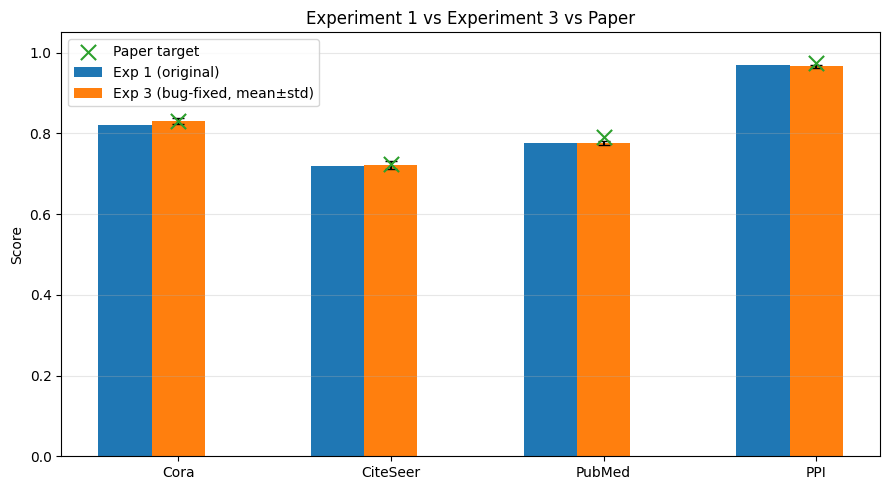

In [13]:
# ============================================================
# E3-7. Compare Experiment 3 vs Experiment 1 vs paper targets
# ============================================================

EXP1_RESULTS = {
    'Cora':     0.820,
    'CiteSeer': 0.718,
    'PubMed':   0.777,
    'PPI':      0.970,
}
paper_targets = {'Cora': 0.830, 'CiteSeer': 0.725, 'PubMed': 0.790, 'PPI': 0.973}

mean_row = exp3_trans_per_seed.mean()
std_row  = exp3_trans_per_seed.std()
mean_f1  = exp3_ppi_per_seed['test_micro_f1'].mean()
std_f1   = exp3_ppi_per_seed['test_micro_f1'].std()

rows = []
for d in RUN_TRANSDUCTIVE_DATASETS:
    rows.append({'dataset': d,
                 'Exp1 (original)': EXP1_RESULTS[d],
                 'Exp3 (mean±std)': f'{mean_row[d]:.4f} ± {std_row[d]:.4f}',
                 'Paper': paper_targets[d]})
rows.append({'dataset': 'PPI',
             'Exp1 (original)': EXP1_RESULTS['PPI'],
             'Exp3 (mean±std)': f'{mean_f1:.4f} ± {std_f1:.4f}',
             'Paper': paper_targets['PPI']})

cmp_df = pd.DataFrame(rows).set_index('dataset')
display(cmp_df)

fig, ax = plt.subplots(figsize=(9, 5))
datasets = list(paper_targets.keys())
x = range(len(datasets))
w = 0.25
ax.bar([i - w for i in x],
       [cmp_df.loc[d, 'Exp1 (original)'] for d in datasets],
       w, label='Exp 1 (original)')
means = [mean_row.get(d, mean_f1) for d in datasets]
stds  = [std_row.get(d,  std_f1)  for d in datasets]
ax.bar(list(x), means, w, yerr=stds, capsize=4, label='Exp 3 (bug-fixed, mean±std)')
ax.scatter(x, [paper_targets[d] for d in datasets],
           marker='x', s=120, zorder=5, label='Paper target')
ax.set_xticks(list(x)); ax.set_xticklabels(datasets)
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Experiment 1 vs Experiment 3 vs Paper')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
